In [1]:
import torch
import torch.nn as nn
import torchvision.models as models
import torch.nn.functional as F
from torch.utils.data import Dataset
from torch.utils.data import DataLoader, random_split
import rasterio
import numpy as np
import glob
import matplotlib.pyplot as plt
import os
from tqdm import tqdm
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix

# Create dataset

Extarct label from the last channel of the image (the last channel is a label mask filled with only 1 value)

In [2]:
class FeatureCubeDataset(Dataset):
    def __init__(self, file_paths, transform=None):
        self.file_paths = file_paths
        self.transform = transform

    def __len__(self):
        return len(self.file_paths)

    def __getitem__(self, idx):
        file = self.file_paths[idx]
        with rasterio.open(file) as src:
            arr = src.read()  # shape: (C, H, W)
        
        # last channel is the label
        # image = arr[:-1].astype(np.float32)  # (C-1, H, W)
        image = arr[:-1].astype(np.float32)  # (C-1, H, W)
        mask = arr[-1].astype(np.int64)      # (H, W)
        label = mask[0, 0]  # Single class label for the entire image
        
        # Sanitize image
        image = np.nan_to_num(image, nan=0.0, posinf=0.0, neginf=0.0)
        
        if self.transform:
                # For classification, we might want different transforms
                # This assumes albumentations transform for image only
                augmented = self.transform(image=image.transpose(1,2,0))
                image = augmented["image"].transpose(2,0,1)
                
        return torch.tensor(image), torch.tensor(label, dtype=torch.long)

# Split dataset

In [3]:
all_files = glob.glob("data/feature_cubes/*.tif")
total_files = len(all_files)

# Define split ratios
train_ratio = 0.7  # 70% for training
val_ratio = 0.2    # 20% for validation
test_ratio = 0.1   # 10% for testing

# Calculate sizes
train_size = int(train_ratio * total_files)
val_size = int(val_ratio * total_files)
test_size = total_files - train_size - val_size  # Ensure all files are used

# Split the dataset
train_files, val_files, test_files = random_split(
    all_files, 
    [train_size, val_size, test_size],
    generator=torch.Generator().manual_seed(42)  # For reproducible splits
)

# Create datasets
train_dataset = FeatureCubeDataset(train_files)
val_dataset = FeatureCubeDataset(val_files)
test_dataset = FeatureCubeDataset(test_files)

# Create data loaders
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16)
test_loader = DataLoader(test_dataset, batch_size=16)

# Import model pretrained on resnet

In [4]:
import segmentation_models_pytorch as smp

model = models.resnet34(pretrained=True)
# Modify first layer for multi-channel input
model.conv1 = nn.Conv2d(in_channels=8, out_channels=64, kernel_size=7, stride=2, padding=3, bias=False)
# Modify final layer
model.fc = nn.Linear(model.fc.in_features, out_features=2)

/home/alin/projects/rospin/.venv/lib/python3.11/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/alin/projects/rospin/.venv/lib/python3.11/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet34_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet34_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [5]:
loss_fn = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

device = "cuda" if torch.cuda.is_available() else "cpu"

In [6]:
def evaluate_model(model, data_loader, device, dataset_name="Test"):
    model.eval()
    total_loss = 0
    all_predictions = []
    all_labels = []
    
    eval_bar = tqdm(data_loader, desc=f"{dataset_name} Evaluation", leave=False)
    
    with torch.no_grad():
        for images, labels in eval_bar:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = loss_fn(outputs, labels)
            total_loss += loss.item()
            
            # Get predictions
            predictions = torch.argmax(outputs, dim=1)
            all_predictions.extend(predictions.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            
            eval_bar.set_postfix(loss=loss.item())
    
    avg_loss = total_loss / len(data_loader)
    
    # Calculate classification metrics
    accuracy = accuracy_score(all_labels, all_predictions)
    precision, recall, f1, _ = precision_recall_fscore_support(
        all_labels, all_predictions, average='weighted'
    )
    
    print(f"{dataset_name} Results:")
    print(f"  Loss: {avg_loss:.4f}")
    print(f"  Accuracy: {accuracy:.4f}")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall: {recall:.4f}")
    print(f"  F1-Score: {f1:.4f}")
    
    # Print confusion matrix
    cm = confusion_matrix(all_labels, all_predictions)
    print(f"  Confusion Matrix:\n{cm}")
    
    return avg_loss, accuracy, precision, recall, f1

# Training

20 epochs, show loss and accuracy after each epoch

In [7]:
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

def train_model():
    model.to(device)
    num_epochs = 20
    
    best_val_accuracy = 0.0
    
    for epoch in range(num_epochs):
        model.train()
        total_loss = 0
        correct_predictions = 0
        total_samples = 0
        
        # Training loop with progress bar
        train_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Train]", leave=False)
        for images, labels in train_bar:
            images, labels = images.to(device), labels.to(device)
            
            optimizer.zero_grad()
            outputs = model(images)  # (B, num_classes)
            
            loss = loss_fn(outputs, labels)
            loss.backward()
            optimizer.step()
            
            total_loss += loss.item()
            predictions = torch.argmax(outputs, dim=1)
            correct_predictions += (predictions == labels).sum().item()
            total_samples += labels.size(0)
            
            train_bar.set_postfix(loss=loss.item())
            
        avg_train_loss = total_loss / len(train_loader)
        train_accuracy = correct_predictions / total_samples
        train_losses.append(avg_train_loss)
        train_accuracies.append(train_accuracy)
        
        print(f"Epoch {epoch+1}, Train Loss: {avg_train_loss:.4f}, Train Accuracy: {train_accuracy:.4f}")
        
        # Validation loop
        val_loss, val_accuracy, _, _, _ = evaluate_model(model, val_loader, device, "Validation")
        val_losses.append(val_loss)
        val_accuracies.append(val_accuracy)
        
        # Save best model
        if val_accuracy > best_val_accuracy:
            best_val_accuracy = val_accuracy
            torch.save(model.state_dict(), "cnn_hydro_best.pth")
            print(f"New best model saved with validation accuracy: {val_accuracy:.4f}")

In [8]:
if os.path.exists("cnn_hydro.pth"):
    model.load_state_dict(torch.load("cnn_hydro.pth", map_location="cpu"))
    model.eval()  # set to inference mode
    losses = torch.load("losses.pth", map_location="cpu")
    train_losses = losses['train_losses']
    val_losses = losses['val_losses']
    train_accuracies = losses['train_acc']
    val_accuracies = losses['val_acc']
    print("Loaded existing model weights.")
    
    model.to(device)
    test_loss, test_accuracy, _, _, _ = evaluate_model(model, test_loader, device, "Test")
else:
    train_model()
    torch.save(model.state_dict(), "cnn_hydro.pth")
    
    torch.save({
        'train_losses': train_losses,
        'val_losses': val_losses,
        'train_acc': train_accuracies,
        'val_acc': val_accuracies
    }, "losses.pth")
    print("Saved model weights to cnn_hydro.pth")
    
    test_loss, test_accuracy, _, _, _ = evaluate_model(model, test_loader, device, "Test")


Loaded existing model weights.


Test Results:
  Loss: 0.0540
  Accuracy: 0.9851
  Precision: 0.9854
  Recall: 0.9851
  F1-Score: 0.9850
  Confusion Matrix:
[[500   0]
 [ 12 291]]


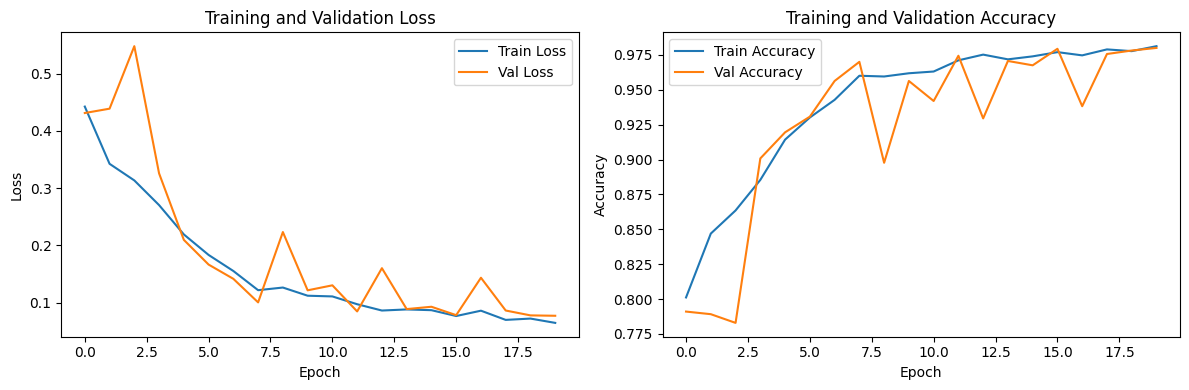

In [9]:
def plot_training_curves():
    if len(train_losses) > 0:
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
        
        # Loss curves
        ax1.plot(train_losses, label='Train Loss')
        ax1.plot(val_losses, label='Val Loss')
        ax1.set_xlabel('Epoch')
        ax1.set_ylabel('Loss')
        ax1.set_title('Training and Validation Loss')
        ax1.legend()
        
        # Accuracy curves
        ax2.plot(train_accuracies, label='Train Accuracy')
        ax2.plot(val_accuracies, label='Val Accuracy')
        ax2.set_xlabel('Epoch')
        ax2.set_ylabel('Accuracy')
        ax2.set_title('Training and Validation Accuracy')
        ax2.legend()
        
        plt.tight_layout()
        plt.savefig('training_curves.png')
        plt.show()

plot_training_curves()

# Make a prediction map


Authenticating with Copernicus Data Space...
AuthData: {'client_id': 'sh-44cc0f70-1627-4ac0-ba80-e14f543237a2', 'client_secret': 'PwJhpkMB81hxXqF71oJdyQsstQUwskfy', 'grant_type': 'client_credentials'}
Token response: 200 {"access_token":"eyJhbGciOiJSUzI1NiIsInR5cCIgOiAiSldUIiwia2lkIiA6ICJYVUh3VWZKaHVDVWo0X3k4ZF8xM0hxWXBYMFdwdDd2anhob2FPLUxzREZFIn0.eyJleHAiOjE3NTcxODQ0MzQsImlhdCI6MTc1NzE4MzgzNCwianRpIjoiNzUzNzliODctYjRmYy00YmZlLWIwYmItNjc0YWNjNDY0MGVjIiwiaXNzIjoiaHR0cHM6Ly9pZGVudGl0eS5kYXRhc3BhY2UuY29wZXJuaWN1cy5ldS9hdXRoL3JlYWxtcy9DRFNFIiwic3ViIjoiYjYwMzMwMmQtMzg5Ny00OGZiLWEzODEtZGM1YzE5ZjBkYzJlIiwidHlwIjoiQmVhcmVyIiwiYXpwIjoic2gtNDRjYzBmNzAtMTYyNy00YWMwLWJhODAtZTE0ZjU0MzIzN2EyIiwic2NvcGUiOiJlbWFpbCBwcm9maWxlIHVzZXItY29udGV4dCIsImNsaWVudEhvc3QiOiI4Mi43OC4yMzIuNDYiLCJlbWFpbF92ZXJpZmllZCI6ZmFsc2UsIm9yZ2FuaXphdGlvbnMiOlsiZGVmYXVsdC1lOTExNDAwZC01NmVhLTRjZTQtYTZlMC0xNjFmNDc1ZTkzYjEiXSwidXNlcl9jb250ZXh0X2lkIjoiNjFhMGM3ZTktNzY4My00Y2JmLTg4NjQtY2QzYjFmMzQ0YWNiIiwiY29udGV4dF9yb2xlcyI6e30sImNvbn

/home/alin/projects/rospin/.venv/lib/python3.11/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/alin/projects/rospin/.venv/lib/python3.11/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet34_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet34_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Model loaded successfully on cuda
Step 1: Creating grid...
Creating grid: 49 x 42 cells
Created grid with 2058 cells

Step 2: Extracting satellite features...
Extracting features for 2058 grid cells...
File temp_grid_data/feature_cube_0.tif already exists. Skipping...
File temp_grid_data/feature_cube_1.tif already exists. Skipping...
File temp_grid_data/feature_cube_2.tif already exists. Skipping...
File temp_grid_data/feature_cube_4.tif already exists. Skipping...
File temp_grid_data/feature_cube_5.tif already exists. Skipping...
File temp_grid_data/feature_cube_3.tif already exists. Skipping...
File temp_grid_data/feature_cube_6.tif already exists. Skipping...
File temp_grid_data/feature_cube_7.tif already exists. Skipping...
File temp_grid_data/feature_cube_8.tif already exists. Skipping...
File temp_grid_data/feature_cube_9.tif already exists. Skipping...
File temp_grid_data/feature_cube_10.tif already exists. Skipping...
File temp_grid_data/feature_cube_11.tif already exists. Skip

Fetching patches in parallel: 100%|██████████| 2058/2058 [00:00<00:00, 197336.14it/s]


File temp_grid_data/feature_cube_1326.tif already exists. Skipping...File temp_grid_data/feature_cube_1328.tif already exists. Skipping...
File temp_grid_data/feature_cube_1334.tif already exists. Skipping...
File temp_grid_data/feature_cube_1335.tif already exists. Skipping...
File temp_grid_data/feature_cube_1336.tif already exists. Skipping...
File temp_grid_data/feature_cube_1337.tif already exists. Skipping...
File temp_grid_data/feature_cube_1338.tif already exists. Skipping...
File temp_grid_data/feature_cube_1339.tif already exists. Skipping...
File temp_grid_data/feature_cube_1340.tif already exists. Skipping...
File temp_grid_data/feature_cube_1341.tif already exists. Skipping...
File temp_grid_data/feature_cube_1342.tif already exists. Skipping...
File temp_grid_data/feature_cube_1343.tif already exists. Skipping...
File temp_grid_data/feature_cube_1344.tif already exists. Skipping...
File temp_grid_data/feature_cube_1345.tif already exists. Skipping...
File temp_grid_data/f

Classifying: 100%|██████████| 2058/2058 [00:10<00:00, 201.36it/s]



Step 4: Classification Summary
  Hydro Potential: 314 cells (15.3%)
  No Hydro: 1744 cells (84.7%)
  Average confidence: 0.947

Step 5: Saving results...
Visualization saved to data/map/classification_map.png


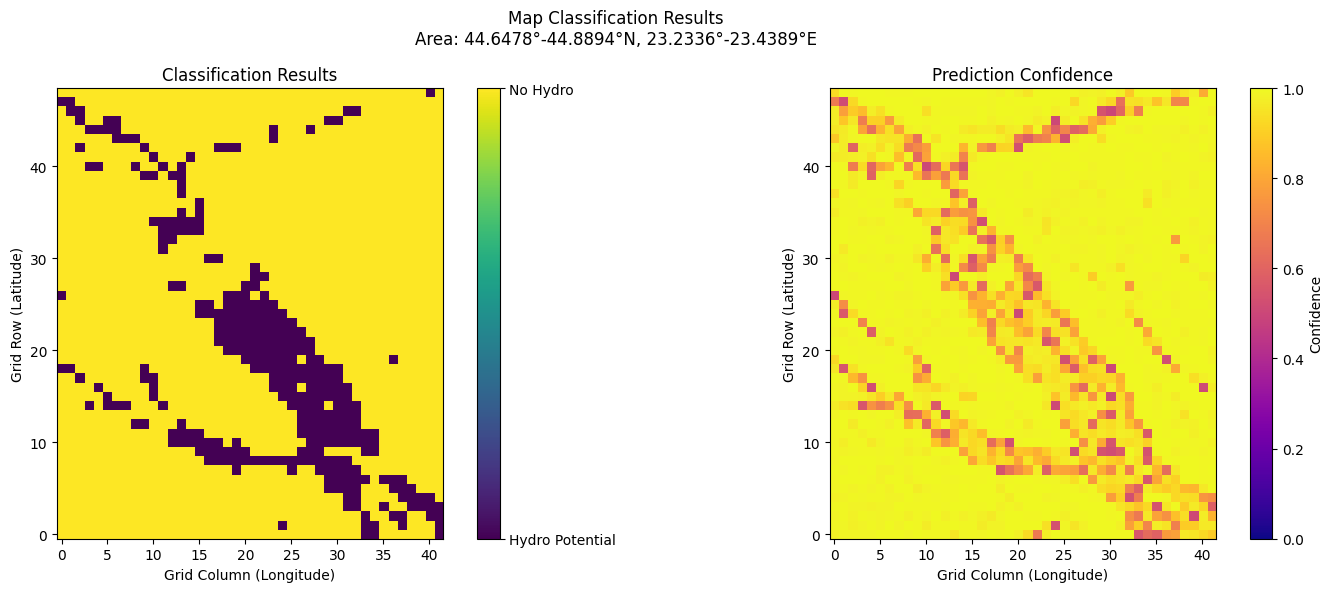

Creating real map overlay...
Interactive map saved to data/map/interactive_map.html
Results saved to data/map/
CLASSIFICATION COMPLETE!
Results saved to: data/map
Classification Summary:
  grid_shape: [49, 42]
  total_cells: 2058
  classified_cells: 2058
  class_distribution: {'Hydro Potential': 314, 'No Hydro': 1744}
  average_confidence: 0.9468207242885067
  output_folder: data/map


In [11]:

from MapClassifier import MapClassifier

def classify_map_area(bbox, model_path, model_name='resnet34', class_names=None, 
                     output_folder='classification_results', temp_folder='temp_grid_data'):
    """
    Main function to classify a map area
    
    Args:
        bbox (list): [min_lon, min_lat, max_lon, max_lat]
        model_path (str): Path to trained model
        model_name (str): Model architecture
        class_names (list): Class names for visualization
        output_folder (str): Output folder for results
        temp_folder (str): Temporary folder for feature extraction
        max_workers (int): Number of parallel workers
        cleanup (bool): Whether to cleanup temporary files
        
    Returns:
        tuple: (predictions_2d, confidences_2d, results_summary)
    """
    print("=" * 60)
    print("MAP AREA CLASSIFICATION")
    print("=" * 60)
    print(f"Bounding box: {bbox}")
    print(f"Model: {model_name} from {model_path}")
    print(f"Output folder: {output_folder}")
    print()
    
    classifier = MapClassifier(model_path, model_name, 2, class_names)
    
    print("Step 1: Creating grid...")
    grid_points, grid_shape, cell_size = classifier.create_grid(bbox)
    print(f"Created grid with {len(grid_points)} cells")
    print()
    
    print("Step 2: Extracting satellite features...")
    feature_files = classifier.extract_features_for_grid(
        grid_points, temp_folder
    )
    print()
    
    print("Step 3: Running classification...")
    predictions_2d, confidences_2d, results_list = classifier.classify_grid(
        feature_files, grid_shape
    )
    print()
    
    valid_predictions = predictions_2d[predictions_2d >= 0]
    if len(valid_predictions) > 0:
        class_counts = np.bincount(valid_predictions)
        print("Step 4: Classification Summary")
        for i, count in enumerate(class_counts):
            class_name = classifier.class_names[i] if i < len(classifier.class_names) else f'Class_{i}'
            percentage = count / len(valid_predictions) * 100
            print(f"  {class_name}: {count} cells ({percentage:.1f}%)")
        
        avg_confidence = np.nanmean(confidences_2d)
        print(f"  Average confidence: {avg_confidence:.3f}")
    print()
    
    print("Step 5: Saving results...")
    classifier.visualize_results(predictions_2d, confidences_2d, bbox, 
                               f"{output_folder}/classification_map.png")
    
        # Create overlay visualization on real map
    print("Creating real map overlay...")
    classifier.create_interactive_map(predictions_2d, confidences_2d, bbox, grid_points, output_folder + "/interactive_map.html")
    
    result_folder = classifier.save_results(
        predictions_2d, confidences_2d, bbox, grid_points, output_folder
    )
    
    # Summary - convert numpy types for JSON compatibility
    results_summary = {
        'grid_shape': [int(dim) for dim in grid_shape],  # Convert to Python int
        'total_cells': int(len(grid_points)),
        'classified_cells': int(len(feature_files)),
        'class_distribution': {name: int(count) for name, count in zip(classifier.class_names, 
                             np.bincount(valid_predictions))} if len(valid_predictions) > 0 else {},
        'average_confidence': float(np.nanmean(confidences_2d)) if not np.isnan(np.nanmean(confidences_2d)) else 0.0,
        'output_folder': str(result_folder)
    }
    
    print("=" * 60)
    print("CLASSIFICATION COMPLETE!")
    print(f"Results saved to: {result_folder}")
    print("=" * 60)
    
    return predictions_2d, confidences_2d, results_summary


bbox = [23.233611, 44.647778, 23.438889, 44.889444]  # [min_lon, min_lat, max_lon, max_lat]
model_path = "cnn_hydro.pth"
class_names = ['Hydro Potential', 'No Hydro']

predictions, confidences, summary = classify_map_area(
    bbox=bbox,
    model_path=model_path,
    model_name='resnet34',
    class_names=class_names,
    output_folder='data/map',
)

print("Classification Summary:")
for key, value in summary.items():
    print(f"  {key}: {value}")